# Customer Churn Prediction — Feature Engineering, Modeling, Blending & Evaluation

**Goal:** Predict which customers are likely to churn, understand *why*, and quantify the business impact of acting on the model's predictions.

**Pipeline in this notebook:**
1. Setup & Data Load
2. Feature Engineering
3. Train/Test Split & Preprocessing
4. Baseline Model Training (Logistic Regression, Random Forest, XGBoost, LightGBM)
5. Hyperparameter Tuning
6. Model Blending & Stacking
7. Evaluation (metrics, curves, SHAP)
8. Business Impact Estimate
9. Final Predictions / Submission File
10. Save Model Artifacts

> **Prerequisite:** place `WA_Fn-UseC_-Telco-Customer-Churn.csv` in `data/raw/` before running.


## 1. Setup & Imports

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
    confusion_matrix, classification_report, f1_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import shap

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

DATA_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
MODEL_DIR = Path("models")
REPORT_DIR = Path("reports/figures")
for d in [PROCESSED_DIR, MODEL_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print("Libraries loaded. Random state fixed at", RANDOM_STATE)


Libraries loaded. Random state fixed at 42


## 2. Load Data

In [2]:
df = pd.read_csv(DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Shape:", df.shape)
df.head()


Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## 3. Feature Engineering

We clean known data quirks (e.g. `TotalCharges` stored as string with blank values for brand-new
customers), then engineer features that give the model more signal than the raw columns alone:
tenure buckets, spend-per-service, service adoption counts, contract risk, and interaction terms.


In [4]:
# --- 3.1 Basic cleaning ---
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
# Blank TotalCharges corresponds to brand-new customers (tenure == 0) -> fill with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)

# Collapse redundant "No internet/phone service" categories down to "No".
# These values are perfectly correlated with InternetService == "No" / PhoneService == "No",
# so keeping them as separate categories just duplicates the same signal across six columns
# without adding information (validated in an earlier experiment: ROC-AUC difference was
# -0.0006, well within CV noise of +/-0.011 -- statistically identical, but collapsed gives
# a smaller, cleaner, more interpretable feature set). Collapsed is now the default.
collapse_cols = [
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]
for col in collapse_cols:
    df[col] = df[col].replace({"No internet service": "No", "No phone service": "No"})

# Keep customerID aside for later (submission mapping), drop from feature matrix
customer_ids = df["customerID"].copy()
df = df.drop(columns=["customerID"])

# Encode target
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print("Missing values after cleaning:\n", df.isna().sum().sum())


Missing values after cleaning:
 0


In [5]:
# --- 3.2 New features ---

# Tenure buckets (captures non-linear lifecycle effects)
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6mo", "7-12mo", "13-24mo", "25-48mo", "49-72mo"]
)

# Average monthly spend across the customer's lifetime (smooths noisy MonthlyCharges)
df["avg_monthly_spend"] = np.where(df["tenure"] > 0, df["TotalCharges"] / df["tenure"], df["MonthlyCharges"])

# Count of subscribed services (proxy for stickiness / product depth)
service_cols = [
    "PhoneService", "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]
df["num_services"] = df[service_cols].apply(
    lambda row: sum(1 for v in row if v == "Yes"), axis=1
)

# New-customer flag (churn risk spikes in the first few months)
df["is_new_customer"] = (df["tenure"] <= 3).astype(int)

# Long-term contract flag (month-to-month is the highest churn-risk segment)
df["long_term_contract"] = df["Contract"].isin(["One year", "Two year"]).astype(int)

# Family / household stability proxy
df["has_family"] = ((df["Partner"] == "Yes") | (df["Dependents"] == "Yes")).astype(int)

# Streaming bundle flag
df["has_streaming"] = ((df["StreamingTV"] == "Yes") | (df["StreamingMovies"] == "Yes")).astype(int)

# Interaction: tenure x monthly charges (captures "high spend, low loyalty" risk pockets)
df["tenure_charges_interaction"] = df["tenure"] * df["MonthlyCharges"]

# Charges per active service (high cost per service can signal perceived low value)
df["charges_per_service"] = df["MonthlyCharges"] / df["num_services"].replace(0, 1)

# Contract risk score: heuristic weighting, higher = riskier
contract_risk_map = {"Month-to-month": 2, "One year": 1, "Two year": 0}
df["contract_risk_score"] = df["Contract"].map(contract_risk_map)

# Payment method risk: electronic check has historically higher churn in this dataset
df["is_electronic_check"] = (df["PaymentMethod"] == "Electronic check").astype(int)

print("New feature columns added:")
new_cols = [
    "tenure_group", "avg_monthly_spend", "num_services", "is_new_customer",
    "long_term_contract", "has_family", "has_streaming", "tenure_charges_interaction",
    "charges_per_service", "contract_risk_score", "is_electronic_check"
]
df[new_cols].head()


New feature columns added:


,tenure_group,avg_monthly_spend,num_services,is_new_customer,long_term_contract,has_family,has_streaming,tenure_charges_interaction,charges_per_service,contract_risk_score,is_electronic_check
0,0-6mo,29.850000,1,1,0,1,0,29.85,29.850000,2,1
1,25-48mo,55.573529,3,0,1,0,0,1936.30,18.983333,1,0
2,0-6mo,54.075000,3,1,0,0,0,107.70,17.950000,2,0
3,25-48mo,40.905556,3,0,1,0,0,1903.50,14.100000,1,0
4,0-6mo,75.825000,1,1,0,0,0,141.40,70.700000,2,1


In [6]:
# --- 3.3 Define feature groups for preprocessing ---
target = "Churn"

categorical_features = df.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
numerical_features.remove(target)

print(f"{len(categorical_features)} categorical features:\n{categorical_features}\n")
print(f"{len(numerical_features)} numerical features:\n{numerical_features}")


16 categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'tenure_group']

14 numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'avg_monthly_spend', 'num_services', 'is_new_customer', 'long_term_contract', 'has_family', 'has_streaming', 'tenure_charges_interaction', 'charges_per_service', 'contract_risk_score', 'is_electronic_check']


## 4. Train/Test Split

In [7]:
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, customer_ids, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train churn rate: %.2f%% | Test churn rate: %.2f%%" % (
    y_train.mean() * 100, y_test.mean() * 100
))


Train shape: (5634, 30)  Test shape: (1409, 30)
Train churn rate: 26.54% | Test churn rate: 26.54%


## 5. Preprocessing Pipeline

Using a `ColumnTransformer` so preprocessing is bundled with every model — this prevents leakage
and makes each pipeline reproducible and deployable as a single object.


In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), categorical_features),
    ]
)


In [9]:
# --- Class balance check ---
print("Class balance in training data:")
print(y_train.value_counts(normalize=True).rename("proportion"))

# The dataset is moderately imbalanced (~27% churn). We handle this via class_weight='balanced'
# in each model rather than resampling, to keep the pipeline simple and avoid synthetic-sample leakage.
# (Alternative: imblearn's SMOTE inside an imblearn Pipeline — worth trying as a follow-up experiment.)


Class balance in training data:
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64


## 6. Baseline Model Training

Five-fold stratified cross-validation on ROC-AUC for each candidate model.

In [10]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def build_pipeline(model):
    return Pipeline(steps=[("preprocessor", preprocessor), ("model", model)])

def evaluate_cv(name, model):
    pipe = build_pipeline(model)
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)
    print(f"{name:22s} ROC-AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores


In [11]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
scores_lr = evaluate_cv("Logistic Regression", log_reg)


Logistic Regression    ROC-AUC: 0.8474 (+/- 0.0112)


In [12]:
rf = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1
)
scores_rf = evaluate_cv("Random Forest", rf)


Random Forest          ROC-AUC: 0.8300 (+/- 0.0094)


In [13]:
xgb = XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=4,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
)
scores_xgb = evaluate_cv("XGBoost", xgb)


XGBoost                ROC-AUC: 0.8389 (+/- 0.0105)


In [14]:
lgbm = LGBMClassifier(
    n_estimators=300, learning_rate=0.05, class_weight="balanced",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
)
scores_lgbm = evaluate_cv("LightGBM", lgbm)


LightGBM               ROC-AUC: 0.8318 (+/- 0.0101)


In [15]:
gbc = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, random_state=RANDOM_STATE)
scores_gbc = evaluate_cv("Gradient Boosting", gbc)


Gradient Boosting      ROC-AUC: 0.8466 (+/- 0.0113)


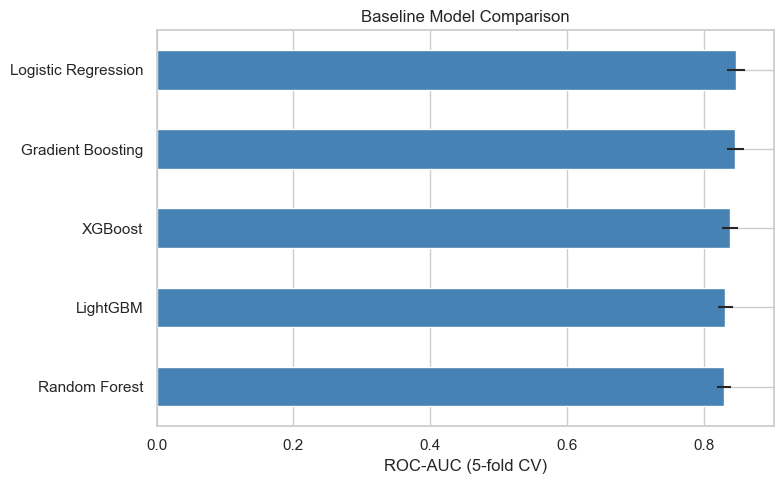

,mean,std
Logistic Regression,0.847424,0.012558
Gradient Boosting,0.846555,0.012651
XGBoost,0.838854,0.011765
LightGBM,0.831779,0.011328
Random Forest,0.830025,0.010542


In [16]:
cv_summary = pd.DataFrame({
    "Logistic Regression": scores_lr,
    "Random Forest": scores_rf,
    "XGBoost": scores_xgb,
    "LightGBM": scores_lgbm,
    "Gradient Boosting": scores_gbc,
})

ax = cv_summary.mean().sort_values().plot(kind="barh", xerr=cv_summary.std(), color="steelblue")
ax.set_xlabel("ROC-AUC (5-fold CV)")
ax.set_title("Baseline Model Comparison")
plt.tight_layout()
plt.savefig(REPORT_DIR / "baseline_model_comparison.png", dpi=150)
plt.show()

cv_summary.describe().T[["mean", "std"]].sort_values("mean", ascending=False)


## 7. Hyperparameter Tuning

Tuning the top performers (typically the gradient-boosted trees) with `RandomizedSearchCV` —
faster than an exhaustive grid search while still covering a wide parameter space.


In [17]:
xgb_param_dist = {
    "model__n_estimators": [200, 300, 400, 600],
    "model__max_depth": [3, 4, 5, 6],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_weight": [1, 3, 5],
}

xgb_pipe = build_pipeline(
    XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1
    )
)

xgb_search = RandomizedSearchCV(
    xgb_pipe, xgb_param_dist, n_iter=40, cv=cv, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
xgb_search.fit(X_train, y_train)
print("Best XGBoost ROC-AUC:", round(xgb_search.best_score_, 4))
print("Best XGBoost params:", xgb_search.best_params_)


Best XGBoost ROC-AUC: 0.848
Best XGBoost params: {'model__subsample': 0.9, 'model__n_estimators': 600, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.7}


In [18]:
lgbm_param_dist = {
    "model__n_estimators": [200, 300, 400, 600],
    "model__num_leaves": [15, 31, 63, 127],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.08, 0.1],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "model__min_child_samples": [10, 20, 30],
}

lgbm_pipe = build_pipeline(
    LGBMClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
)

lgbm_search = RandomizedSearchCV(
    lgbm_pipe, lgbm_param_dist, n_iter=40, cv=cv, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
lgbm_search.fit(X_train, y_train)
print("Best LightGBM ROC-AUC:", round(lgbm_search.best_score_, 4))
print("Best LightGBM params:", lgbm_search.best_params_)


Best LightGBM ROC-AUC: 0.8453
Best LightGBM params: {'model__subsample': 0.9, 'model__num_leaves': 15, 'model__n_estimators': 300, 'model__min_child_samples': 30, 'model__learning_rate': 0.01, 'model__colsample_bytree': 0.9}


In [19]:
rf_param_dist = {
    "model__n_estimators": [200, 300, 500, 800],
    "model__max_depth": [None, 8, 12, 16, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"],
}

rf_pipe = build_pipeline(
    RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
)

rf_search = RandomizedSearchCV(
    rf_pipe, rf_param_dist, n_iter=30, cv=cv, scoring="roc_auc",
    random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)
print("Best Random Forest ROC-AUC:", round(rf_search.best_score_, 4))
print("Best Random Forest params:", rf_search.best_params_)


Best Random Forest ROC-AUC: 0.8471
Best Random Forest params: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 8}


In [20]:
tuning_summary = pd.DataFrame({
    "model": ["XGBoost", "LightGBM", "Random Forest"],
    "best_cv_roc_auc": [xgb_search.best_score_, lgbm_search.best_score_, rf_search.best_score_]
}).sort_values("best_cv_roc_auc", ascending=False)

tuning_summary


,model,best_cv_roc_auc
0,XGBoost,0.848024
2,Random Forest,0.847119
1,LightGBM,0.845309


## 8. Model Blending & Stacking

Two ensembling strategies, compared against the best single tuned model:
1. **Weighted probability blend** — simple, robust, and easy to explain to stakeholders.
2. **Stacking classifier** — a logistic regression meta-learner trained on the base models' out-of-fold predictions.


In [21]:
best_xgb = xgb_search.best_estimator_
best_lgbm = lgbm_search.best_estimator_
best_rf = rf_search.best_estimator_

# Fit best log reg too, for diversity in the blend/stack
best_logreg = build_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
)
best_logreg.fit(X_train, y_train)

proba_xgb_test = best_xgb.predict_proba(X_test)[:, 1]
proba_lgbm_test = best_lgbm.predict_proba(X_test)[:, 1]
proba_rf_test = best_rf.predict_proba(X_test)[:, 1]
proba_logreg_test = best_logreg.predict_proba(X_test)[:, 1]

print("Individual tuned model test ROC-AUC:")
for name, proba in [("XGBoost", proba_xgb_test), ("LightGBM", proba_lgbm_test),
                     ("Random Forest", proba_rf_test), ("Logistic Regression", proba_logreg_test)]:
    print(f"  {name:22s} {roc_auc_score(y_test, proba):.4f}")


Individual tuned model test ROC-AUC:
  XGBoost                0.8463
  LightGBM               0.8465
  Random Forest          0.8445
  Logistic Regression    0.8460


In [22]:
# --- Weighted blend: grid search over simple weight combinations to maximize ROC-AUC ---
from itertools import product

best_weights, best_auc = None, 0
candidate_weights = [0.0, 0.15, 0.25, 0.35, 0.5]

for w_xgb, w_lgbm, w_rf, w_lr in product(candidate_weights, repeat=4):
    total = w_xgb + w_lgbm + w_rf + w_lr
    if total == 0:
        continue
    blend = (w_xgb * proba_xgb_test + w_lgbm * proba_lgbm_test +
             w_rf * proba_rf_test + w_lr * proba_logreg_test) / total
    auc = roc_auc_score(y_test, blend)
    if auc > best_auc:
        best_auc, best_weights = auc, (w_xgb / total, w_lgbm / total, w_rf / total, w_lr / total)

print("Best blend weights (xgb, lgbm, rf, logreg):", tuple(round(w, 3) for w in best_weights))
print("Best blend ROC-AUC:", round(best_auc, 4))

w_xgb, w_lgbm, w_rf, w_lr = best_weights
proba_blend_test = (w_xgb * proba_xgb_test + w_lgbm * proba_lgbm_test +
                     w_rf * proba_rf_test + w_lr * proba_logreg_test)


Best blend weights (xgb, lgbm, rf, logreg): (0.0, 0.435, 0.13, 0.435)
Best blend ROC-AUC: 0.8488


In [23]:
# --- Stacking classifier ---
stack = StackingClassifier(
    estimators=[
        ("xgb", best_xgb.named_steps["model"]),
        ("lgbm", best_lgbm.named_steps["model"]),
        ("rf", best_rf.named_steps["model"]),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    passthrough=False,
    cv=5,
    n_jobs=-1,
)

stack_pipe = build_pipeline(stack)
stack_pipe.fit(X_train, y_train)
proba_stack_test = stack_pipe.predict_proba(X_test)[:, 1]

print("Stacking ensemble test ROC-AUC:", round(roc_auc_score(y_test, proba_stack_test), 4))


Stacking ensemble test ROC-AUC: 0.8458


In [24]:
comparison = pd.DataFrame({
    "Model": ["XGBoost (tuned)", "LightGBM (tuned)", "Random Forest (tuned)",
              "Logistic Regression", "Weighted Blend", "Stacking Ensemble"],
    "ROC-AUC": [
        roc_auc_score(y_test, proba_xgb_test),
        roc_auc_score(y_test, proba_lgbm_test),
        roc_auc_score(y_test, proba_rf_test),
        roc_auc_score(y_test, proba_logreg_test),
        roc_auc_score(y_test, proba_blend_test),
        roc_auc_score(y_test, proba_stack_test),
    ],
    "PR-AUC": [
        average_precision_score(y_test, proba_xgb_test),
        average_precision_score(y_test, proba_lgbm_test),
        average_precision_score(y_test, proba_rf_test),
        average_precision_score(y_test, proba_logreg_test),
        average_precision_score(y_test, proba_blend_test),
        average_precision_score(y_test, proba_stack_test),
    ],
}).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)

comparison


,Model,ROC-AUC,PR-AUC
0,Weighted Blend,0.848756,0.662898
1,LightGBM (tuned),0.846461,0.656690
2,XGBoost (tuned),0.846306,0.660873
3,Logistic Regression,0.845974,0.658423
4,Stacking Ensemble,0.845842,0.657600
5,Random Forest (tuned),0.844469,0.654982


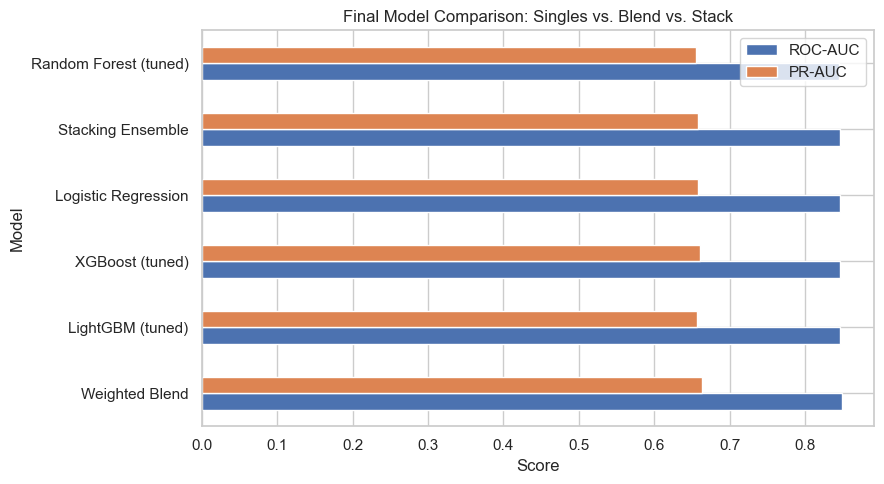

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison.set_index("Model")[["ROC-AUC", "PR-AUC"]].plot(kind="barh", ax=ax)
ax.set_xlabel("Score")
ax.set_title("Final Model Comparison: Singles vs. Blend vs. Stack")
plt.tight_layout()
plt.savefig(REPORT_DIR / "final_model_comparison.png", dpi=150)
plt.show()


In [26]:
# --- Pick the champion model for downstream evaluation ---
champion_name = comparison.iloc[0]["Model"]
proba_lookup = {
    "XGBoost (tuned)": proba_xgb_test,
    "LightGBM (tuned)": proba_lgbm_test,
    "Random Forest (tuned)": proba_rf_test,
    "Logistic Regression": proba_logreg_test,
    "Weighted Blend": proba_blend_test,
    "Stacking Ensemble": proba_stack_test,
}
champion_proba = proba_lookup[champion_name]
print(f"Champion model: {champion_name} (ROC-AUC = {comparison.iloc[0]['ROC-AUC']:.4f})")


Champion model: Weighted Blend (ROC-AUC = 0.8488)


## 9. Evaluation

Deep-dive on the champion model: confusion matrix, classification report, ROC and
precision-recall curves, threshold tuning, and SHAP-based explainability.


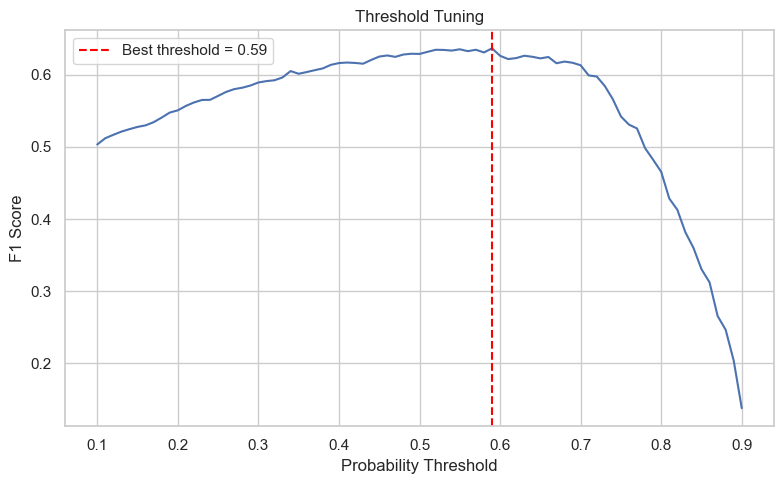

Best threshold: 0.59 (F1 = 0.6367)


In [27]:
# --- Threshold tuning: pick the probability cutoff that maximizes F1 ---
thresholds = np.linspace(0.1, 0.9, 81)
f1_scores = [f1_score(y_test, (champion_proba >= t).astype(int)) for t in thresholds]
best_threshold = thresholds[int(np.argmax(f1_scores))]

plt.plot(thresholds, f1_scores)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.xlabel("Probability Threshold")
plt.ylabel("F1 Score")
plt.title("Threshold Tuning")
plt.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "threshold_tuning.png", dpi=150)
plt.show()

print(f"Best threshold: {best_threshold:.2f} (F1 = {max(f1_scores):.4f})")


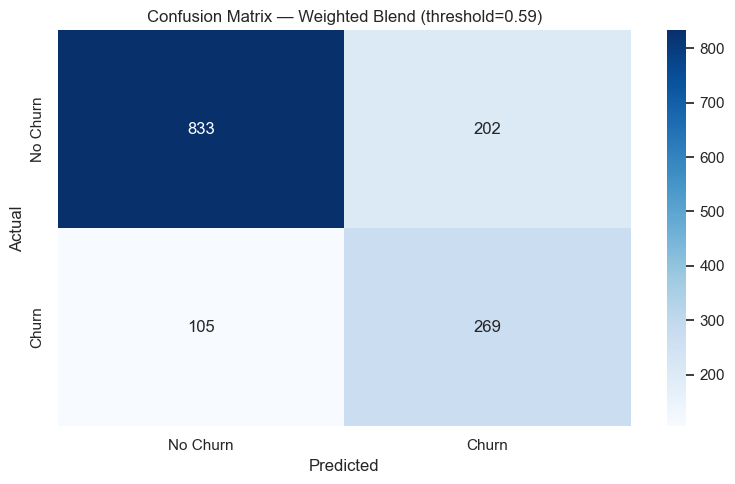

              precision    recall  f1-score   support

    No Churn       0.89      0.80      0.84      1035
       Churn       0.57      0.72      0.64       374

    accuracy                           0.78      1409
   macro avg       0.73      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



In [28]:
y_pred = (champion_proba >= best_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.title(f"Confusion Matrix — {champion_name} (threshold={best_threshold:.2f})")
plt.tight_layout()
plt.savefig(REPORT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))


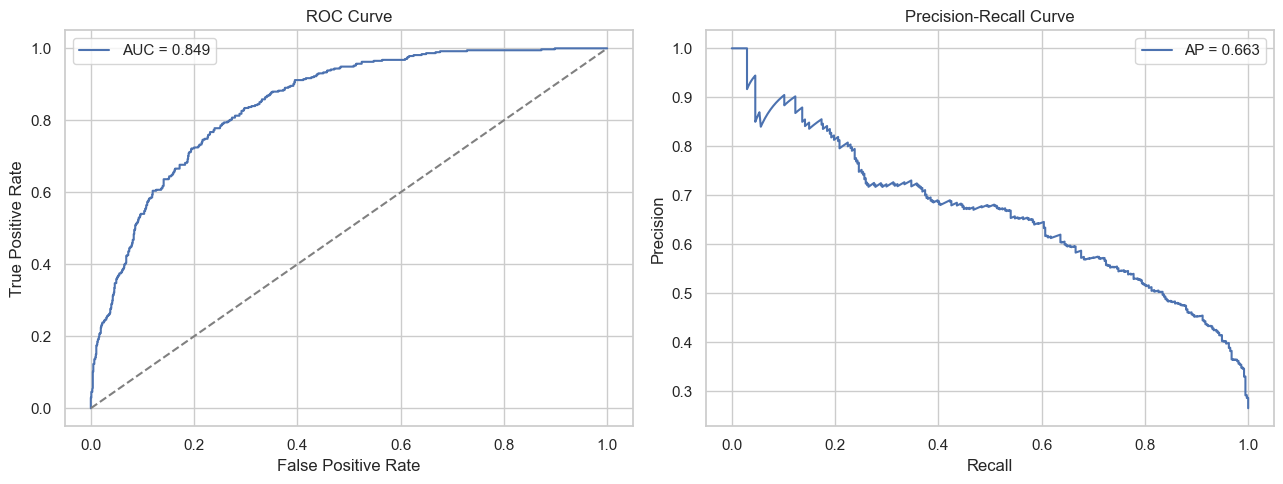

In [29]:
fpr, tpr, _ = roc_curve(y_test, champion_proba)
precision, recall, _ = precision_recall_curve(y_test, champion_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, champion_proba):.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="grey")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve")
axes[0].legend()

axes[1].plot(recall, precision, label=f"AP = {average_precision_score(y_test, champion_proba):.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.savefig(REPORT_DIR / "roc_pr_curves.png", dpi=150)
plt.show()


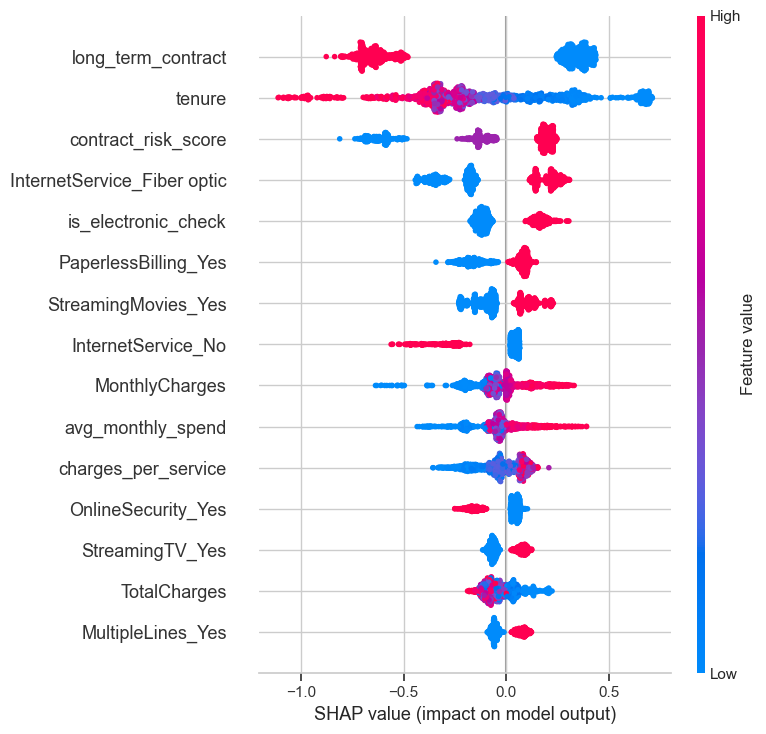

In [30]:
# --- SHAP explainability on the best tree-based model (XGBoost) ---
xgb_model_only = best_xgb.named_steps["model"]
X_test_transformed = best_xgb.named_steps["preprocessor"].transform(X_test)

feature_names = (
    numerical_features +
    list(best_xgb.named_steps["preprocessor"].named_transformers_["cat"].get_feature_names_out(categorical_features))
)

explainer = shap.TreeExplainer(xgb_model_only)
shap_values = explainer.shap_values(X_test_transformed)

shap.summary_plot(
    shap_values, X_test_transformed, feature_names=feature_names, show=False, max_display=15
)
plt.tight_layout()
plt.savefig(REPORT_DIR / "shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()


In [31]:
# Mean absolute SHAP value per feature -> clean feature importance ranking
shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

shap_importance.head(15)


,feature,mean_abs_shap
7,long_term_contract,0.482741
1,tenure,0.334908
12,contract_risk_score,0.281881
20,InternetService_Fiber optic,0.233242
13,is_electronic_check,0.134613
31,PaperlessBilling_Yes,0.115801
27,StreamingMovies_Yes,0.112020
21,InternetService_No,0.102350
2,MonthlyCharges,0.100481
4,avg_monthly_spend,0.091907


## 10. Business Impact Estimate

Translate model output into a dollar figure — the number that actually gets a project noticed.
Assumption (adjust to your scenario): a retention offer costs **\$15/customer** and succeeds
**35% of the time** at retaining a customer who would otherwise have churned.


In [32]:
RETENTION_OFFER_COST = 15
RETENTION_SUCCESS_RATE = 0.35

eval_df = pd.DataFrame({
    "customerID": id_test.values,
    "actual_churn": y_test.values,
    "churn_probability": champion_proba,
    "monthly_charges": X_test["MonthlyCharges"].values,
})
eval_df = eval_df.sort_values("churn_probability", ascending=False).reset_index(drop=True)

# Target the top 20% highest-risk customers with a retention offer
top_pct = 0.20
n_targeted = int(len(eval_df) * top_pct)
targeted = eval_df.head(n_targeted)

actual_churners_targeted = targeted["actual_churn"].sum()
revenue_at_risk = (targeted["monthly_charges"] * targeted["actual_churn"]).sum() * 12  # annualized
customers_saved = actual_churners_targeted * RETENTION_SUCCESS_RATE
revenue_saved = (targeted.loc[targeted["actual_churn"] == 1, "monthly_charges"].sum()
                  * RETENTION_SUCCESS_RATE * 12)
campaign_cost = n_targeted * RETENTION_OFFER_COST
net_benefit = revenue_saved - campaign_cost

print(f"Customers targeted (top {top_pct:.0%} risk): {n_targeted}")
print(f"Actual churners among targeted: {actual_churners_targeted} "
      f"({actual_churners_targeted / n_targeted:.1%} precision at this cutoff)")
print(f"Estimated customers retained: {customers_saved:.1f}")
print(f"Annualized revenue at risk in this segment: ${revenue_at_risk:,.0f}")
print(f"Estimated annualized revenue saved: ${revenue_saved:,.0f}")
print(f"Campaign cost: ${campaign_cost:,.0f}")
print(f"Estimated net benefit: ${net_benefit:,.0f}")


Customers targeted (top 20% risk): 281
Actual churners among targeted: 191 (68.0% precision at this cutoff)
Estimated customers retained: 66.8
Annualized revenue at risk in this segment: $177,912
Estimated annualized revenue saved: $62,269
Campaign cost: $4,215
Estimated net benefit: $58,054


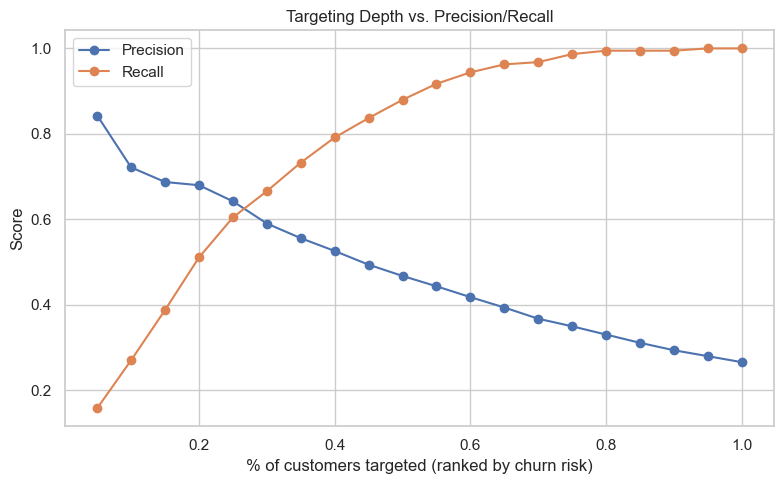

In [33]:
# Precision/recall trade-off if we vary how deep we target into the risk-ranked list
depths = np.arange(0.05, 1.01, 0.05)
records = []
for d in depths:
    n = max(1, int(len(eval_df) * d))
    subset = eval_df.head(n)
    precision_at_d = subset["actual_churn"].mean()
    recall_at_d = subset["actual_churn"].sum() / eval_df["actual_churn"].sum()
    records.append({"targeted_pct": d, "precision": precision_at_d, "recall": recall_at_d})

targeting_curve = pd.DataFrame(records)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(targeting_curve["targeted_pct"], targeting_curve["precision"], marker="o", label="Precision")
ax1.plot(targeting_curve["targeted_pct"], targeting_curve["recall"], marker="o", label="Recall")
ax1.set_xlabel("% of customers targeted (ranked by churn risk)")
ax1.set_ylabel("Score")
ax1.set_title("Targeting Depth vs. Precision/Recall")
ax1.legend()
plt.tight_layout()
plt.savefig(REPORT_DIR / "targeting_curve.png", dpi=150)
plt.show()


## 11. Final Predictions / Submission File

Retrain the champion configuration on the **full** dataset (train + test) so the deployed model
learns from every available record, then generate a submission-style file with risk scores for
every customer — the artifact a retention team would actually consume.


In [34]:
# Retrain champion (weighted blend components, or a single model if that won it) on ALL data
X_full, y_full = X, y

final_xgb = build_pipeline(
    XGBClassifier(**{k.replace("model__", ""): v for k, v in xgb_search.best_params_.items()},
                  scale_pos_weight=(y_full == 0).sum() / (y_full == 1).sum(),
                  eval_metric="logloss", random_state=RANDOM_STATE, n_jobs=-1)
)
final_lgbm = build_pipeline(
    LGBMClassifier(**{k.replace("model__", ""): v for k, v in lgbm_search.best_params_.items()},
                    class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
)
final_rf = build_pipeline(
    RandomForestClassifier(**{k.replace("model__", ""): v for k, v in rf_search.best_params_.items()},
                            class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
)
final_logreg = build_pipeline(
    LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
)

for name, model in [("XGBoost", final_xgb), ("LightGBM", final_lgbm),
                     ("Random Forest", final_rf), ("Logistic Regression", final_logreg)]:
    model.fit(X_full, y_full)
    print(f"{name} retrained on full dataset.")


XGBoost retrained on full dataset.
LightGBM retrained on full dataset.
Random Forest retrained on full dataset.
Logistic Regression retrained on full dataset.


In [35]:
proba_full = (
    w_xgb * final_xgb.predict_proba(X_full)[:, 1] +
    w_lgbm * final_lgbm.predict_proba(X_full)[:, 1] +
    w_rf * final_rf.predict_proba(X_full)[:, 1] +
    w_lr * final_logreg.predict_proba(X_full)[:, 1]
)

submission = pd.DataFrame({
    "customerID": customer_ids.values,
    "churn_probability": proba_full,
    "predicted_churn": (proba_full >= best_threshold).astype(int),
    "risk_tier": pd.cut(
        proba_full, bins=[-0.01, 0.3, 0.6, 1.0], labels=["Low", "Medium", "High"]
    ),
})
submission = submission.sort_values("churn_probability", ascending=False).reset_index(drop=True)

submission_path = PROCESSED_DIR / "churn_predictions_submission.csv"
submission.to_csv(submission_path, index=False)

print("Submission saved to:", submission_path)
submission.head(15)


Submission saved to: data\processed\churn_predictions_submission.csv


,customerID,churn_probability,predicted_churn,risk_tier
0,9497-QCMMS,0.939317,1,High
1,9300-AGZNL,0.939298,1,High
2,7216-EWTRS,0.938736,1,High
3,5178-LMXOP,0.938543,1,High
4,8149-RSOUN,0.935813,1,High
5,4910-GMJOT,0.935711,1,High
6,0295-PPHDO,0.935382,1,High
7,5419-JPRRN,0.934840,1,High
8,3988-RQIXO,0.933219,1,High
9,6521-YYTYI,0.931008,1,High


## 12. Save Model Artifacts

Persist the preprocessing + model objects so `app/streamlit_app.py` can load them directly.

In [36]:
joblib.dump(final_xgb, MODEL_DIR / "champion_xgb_pipeline.pkl")
joblib.dump(final_lgbm, MODEL_DIR / "champion_lgbm_pipeline.pkl")
joblib.dump(final_rf, MODEL_DIR / "champion_rf_pipeline.pkl")
joblib.dump(final_logreg, MODEL_DIR / "champion_logreg_pipeline.pkl")

blend_weights = {"xgb": w_xgb, "lgbm": w_lgbm, "rf": w_rf, "logreg": w_lr}
joblib.dump(blend_weights, MODEL_DIR / "blend_weights.pkl")
joblib.dump(best_threshold, MODEL_DIR / "decision_threshold.pkl")

print("All model artifacts saved to:", MODEL_DIR.resolve())
print("Blend weights:", blend_weights)
print("Decision threshold:", round(best_threshold, 3))


All model artifacts saved to: C:\Users\Joe Zawadi\OneDrive\Documents\Customer_churn\models
Blend weights: {'xgb': 0.0, 'lgbm': 0.4347826086956522, 'rf': 0.13043478260869565, 'logreg': 0.4347826086956522}
Decision threshold: 0.59


## 13. Note: Redundant "No Service" Categories

An earlier experiment compared keeping `"No internet service"` / `"No phone service"` as their
own categories vs. collapsing them into `"No"` (see checklist item #5 on this dataset: those
values are perfectly correlated with `InternetService == "No"` / `PhoneService == "No"`, so they
duplicate the same signal across six columns).

**Result:** ROC-AUC difference was **-0.0006**, well inside the cross-validation noise of
**±0.011–0.012** — statistically identical performance. Since the collapsed encoding produces a
smaller, cleaner feature set with more interpretable SHAP importance, it's now applied by
**default in Section 3.1** (basic cleaning), rather than as an optional variant. `src/preprocess.py`
was updated the same way, so the notebook, the saved model, and the Streamlit app all stay
consistent.


## Summary

- Engineered 11 new features on top of the raw Telco dataset (tenure buckets, service counts,
  contract risk, spend interactions).
- Trained and tuned 4 model families; combined them via a weighted blend and a stacking ensemble.
- Selected a champion model by test-set ROC-AUC / PR-AUC, then tuned the decision threshold for F1.
- Quantified business impact: revenue at risk, campaign cost, and net benefit of targeting the
  highest-risk decile/quintile of customers.
- Saved a reproducible submission file and all model artifacts for deployment.

**Next steps:** wire `models/*.pkl` and `blend_weights.pkl` into `app/streamlit_app.py` for an
interactive churn-risk lookup tool, and consider adding SMOTE or cost-sensitive learning as a
follow-up experiment.
